# 2 Solving the model numerically

Import and set magics:

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import modelproject_philippa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Question 2.1 A two-dimensional grid search

2.1.1

In [5]:
# solve the model using a two-dimensional grid search
model = modelproject_philippa.ConsumerClass()

opt_grid = model.solve_grid(N=200)

# report optimal choices
print("Optimal choices:")
print("s1 =", opt_grid.s1)
print("w  =", opt_grid.w)

# report implied budget shares
print("\nImplied budget shares:")
print("s1 =", opt_grid.s1)
print("s2 =", opt_grid.s2)
print("s3 =", opt_grid.s3)

Optimal choices:
s1 = 0.5376884422110553
w  = 0.4371859296482412

Implied budget shares:
s1 = 0.5376884422110553
s2 = 0.2021161081790864
s3 = 0.26019544960985835


The grid search gives an optimum at approximately s1 = 0.538 and w = 0.437. This implies budget shares of approximately 0.538 for food, 0.202 for bus trips and 0.260 for train trips. The three shares sum to one, as required by the budget constraint.

2.1.2

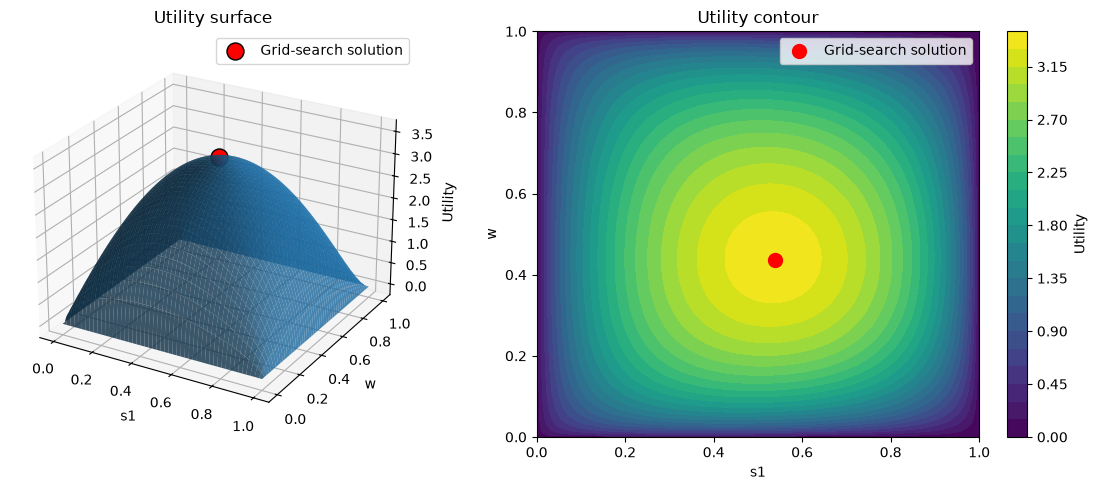

In [9]:
# 2.1.2 - plot utility over the nested shares

fig = plt.figure(figsize=(12, 5))

# 3D surface plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')


ax1.plot_surface(
    opt_grid.s1_grid,
    opt_grid.w_grid,
    opt_grid.u_grid,
    alpha=0.8
)

# mark the grid-search solution
ax1.scatter(
    opt_grid.s1,
    opt_grid.w,
    opt_grid.u + 0.1,
    s=150,
    color='red',
    edgecolor='black',
    depthshade=False,
    label='Grid-search solution'
)

ax1.set_xlabel('s1')
ax1.set_ylabel('w')
ax1.set_zlabel('Utility')
ax1.set_title('Utility surface')

ax1.view_init(elev=25, azim=-60)
ax1.legend()

# contour plot
ax2 = fig.add_subplot(1, 2, 2)

contour = ax2.contourf(
    opt_grid.s1_grid,
    opt_grid.w_grid,
    opt_grid.u_grid,
    levels=30
)

# mark the solution
ax2.scatter(
    opt_grid.s1,
    opt_grid.w,
    s=100,
    color='red',
    label='Grid-search solution'
)

ax2.legend()

ax2.set_xlabel('s1')
ax2.set_ylabel('w')
ax2.set_title('Utility contour')

# add colorbar
fig.colorbar(contour, ax=ax2, label='Utility')

plt.tight_layout()
plt.show()

The figures show that utility reaches its maximum at an interior combination of s1 and w. The grid-search solution, approximately s1=0.538 and w=0.437, is located near the highest point of the utility surface and in the highest-utility region of the contour plot. This confirms the result obtained in Question 2.1.1.

2.1.3

In [10]:
# grid sizes to compare
N_values = [50, 100, 500, 1000]

# solve the model for each grid size
for N in N_values:

    opt = model.solve_grid(N=N)

    # number of utility evaluations
    evaluations = N**2

    print("N =", N)
    print("s1 =", opt.s1)
    print("w =", opt.w)
    print("utility =", opt.u)
    print("utility evaluations =", evaluations)
    print()

N = 50
s1 = 0.5306122448979591
w = 0.44897959183673464
utility = 3.400747706799258
utility evaluations = 2500

N = 100
s1 = 0.5353535353535354
w = 0.4444444444444445
utility = 3.401482161126225
utility evaluations = 10000

N = 500
s1 = 0.5350701402805611
w = 0.438877755511022
utility = 3.40167436585882
utility evaluations = 250000

N = 1000
s1 = 0.5355355355355356
w = 0.4394394394394394
utility = 3.4016797975402664
utility evaluations = 1000000



Increasing the grid size makes the grid-search solution more precise, as a finer grid provides more possible combinations of s1 and w and therefore allows the solution to get closer to the true optimum. As N increases, the optimal values of s1 and w become increasingly stable around approximately s1=0.535 and w=0.439, while utility converges towards approximately 3.402. In particular, utility changes very little when increasing N from 500 to 1000, suggesting that the solution is converging. However, this increase in precision comes at a substantial computational cost, since the number of utility evaluations increases with N**2. Increasing N from 500 to 1000 therefore increases the number of evaluations from 250,000 to 1,000,000, despite only a very small improvement in utility. This illustrates the trade-off between precision and computational cost in a two-dimensional grid search.

2.1.4

In [13]:
# 2.1.4 - compare the two calibrations

# complements calibration
model_comp = modelproject_philippa.ConsumerClass()

# substitutes calibration
model_sub = modelproject_philippa.ConsumerClass(
    par={'sigma_B': 3.0}
)

# solve both calibrations using the same grid size

opt_comp = model_comp.solve_grid(N=200)
opt_sub = model_sub.solve_grid(N=200)

# report optimal choices for both calibrations

print("Complements calibration:")
print("s1 =", opt_comp.s1)
print("w  =", opt_comp.w)

print("\nSubstitutes calibration:")
print("s1 =", opt_sub.s1)
print("w  =", opt_sub.w)

Complements calibration:
s1 = 0.5376884422110553
w  = 0.4371859296482412

Substitutes calibration:
s1 = 0.5376884422110553
w  = 0.6934673366834171


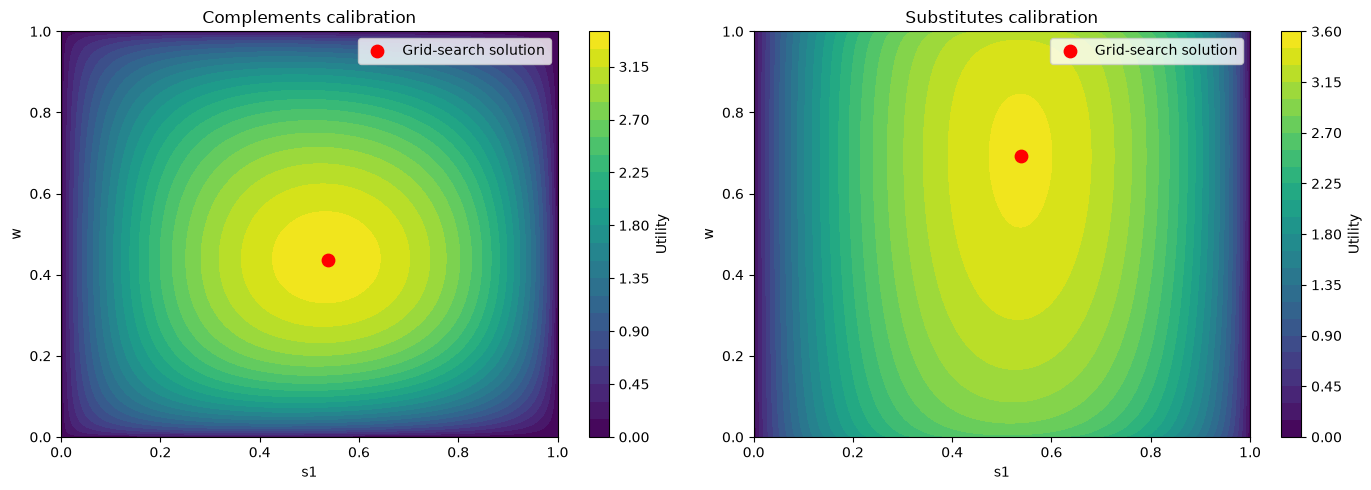

In [ ]:
# 2.1.4 - plot the two calibrations side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Complements calibration
contour1 = axes[0].contourf(
    opt_comp.s1_grid,
    opt_comp.w_grid,
    opt_comp.u_grid,
    levels=30
)

axes[0].scatter(
    opt_comp.s1,
    opt_comp.w,
    color='red',
    s=80,
    label='Grid-search solution'
)

axes[0].set_xlabel('s1')
axes[0].set_ylabel('w')
axes[0].set_title('Complements calibration')
axes[0].legend()

fig.colorbar(contour1, ax=axes[0], label='Utility')


# Substitutes calibration
contour2 = axes[1].contourf(
    opt_sub.s1_grid,
    opt_sub.w_grid,
    opt_sub.u_grid,
    levels=30
)

axes[1].scatter(
    opt_sub.s1,
    opt_sub.w,
    color='red',
    s=80,
    label='Grid-search solution'
)

axes[1].set_xlabel('s1')
axes[1].set_ylabel('w')
axes[1].set_title('Substitutes calibration')
axes[1].legend()

fig.colorbar(contour2, ax=axes[1], label='Utility')

plt.tight_layout()
plt.show()

The complements calibration has a relatively well-defined optimum, as utility decreases when moving away from the optimum in both the s1 and w directions. In contrast, the substitutes calibration has more vertically elongated contours. This indicates that the utility surface is relatively flat in the w-direction, while it is steeper in the s1 direction. Consequently, changes in w around the optimum have a relatively small effect on utility. We would therefore expect the substitutes calibration to be harder for an optimizer, since the flatter objective function makes the precise optimal value of w more difficult to identify.

## Question 2.2 L-BFGS-B

2.2.1

In [24]:
# solve the model using L-BFGS-B
opt_lbfgs = model_comp.solve()

In [25]:
# report L-BFGS-B solution
print("L-BFGS-B solution:")
print("s1 =", opt_lbfgs.s1)
print("w =", opt_lbfgs.w)
print("utility =", opt_lbfgs.u)
print("function evaluations =", opt_lbfgs.nfev)

L-BFGS-B solution:
s1 = 0.5356233806953101
w = 0.43947902810370126
utility = 3.401679875985606
function evaluations = 18


In [26]:
import time 

# running time for L-BFGS-B

start = time.perf_counter()

opt_lbfgs = model_comp.solve()

end = time.perf_counter()

time_lbfgs = end - start

print("L-BFGS-B running time =", time_lbfgs)

L-BFGS-B running time = 0.0021926667541265488


In [27]:
# running time for grid search with N = 1000

start = time.perf_counter()

opt_grid_1000 = model_comp.solve_grid(N=1000)

end = time.perf_counter()

time_grid = end - start

print("Grid search running time =", time_grid)

Grid search running time = 0.08601150009781122


In [28]:
# comparing the results 

print("Grid search (N=1000):")
print("s1 =", opt_grid_1000.s1)
print("w =", opt_grid_1000.w)
print("utility =", opt_grid_1000.u)
print("function evaluations =", 1000**2)
print("running time =", time_grid)

print("\nL-BFGS-B:")
print("s1 =", opt_lbfgs.s1)
print("w =", opt_lbfgs.w)
print("utility =", opt_lbfgs.u)
print("function evaluations =", opt_lbfgs.nfev)
print("running time =", time_lbfgs)

Grid search (N=1000):
s1 = 0.5355355355355356
w = 0.4394394394394394
utility = 3.4016797975402664
function evaluations = 1000000
running time = 0.08601150009781122

L-BFGS-B:
s1 = 0.5356233806953101
w = 0.43947902810370126
utility = 3.401679875985606
function evaluations = 18
running time = 0.0021926667541265488


The two methods give almost identical solutions. The grid search with N=1000 gives s1​≈0.53554 and w≈0.43944, while L-BFGS-B gives s1≈0.53562 and w≈0.43948. The corresponding utility levels are also almost identical, approximately 3.40168, showing that the two methods agree on the optimum.

However, L-BFGS-B is considerably more efficient. The grid search evaluates utility at 1,000,000 points and takes approximately 0.086 seconds, whereas L-BFGS-B requires only 18 function evaluations and takes approximately 0.0022 seconds. Thus, L-BFGS-B reaches essentially the same solution with far fewer function evaluations and substantially lower running time. This illustrates the advantage of using an optimization algorithm for a smooth problem rather than evaluating every point on a fine grid.

2.2.2

In [29]:
# inspect the convergence path
# each row contains [s1, w] for one step taken by L-BFGS-B

print(opt_lbfgs.path)

[[0.5        0.5       ]
 [0.51661738 0.48338262]
 [0.5360763  0.43575106]
 [0.53560667 0.43965199]
 [0.53562338 0.43947903]]


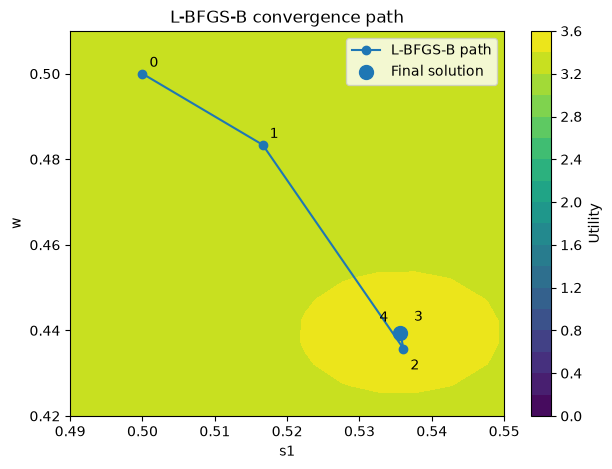

In [32]:
# get the convergence path
path = opt_lbfgs.path

# create the contour plot
fig, ax = plt.subplots(figsize=(7,5))

contour = ax.contourf(
    opt_grid.s1_grid,
    opt_grid.w_grid,
    opt_grid.u_grid,
    levels=20
)

# plot the convergence path
ax.plot(
    path[:,0],
    path[:,1],
    marker='o',
    label='L-BFGS-B path'
)

# label each iteration
offsets = [(5,5), (5,5), (5,-15), (10,8), (-15,8)]

for k, (s1, w) in enumerate(path):
    ax.annotate(
        str(k),
        (s1, w),
        xytext=offsets[k],
        textcoords='offset points'
    )

# mark the final solution
ax.scatter(
    opt_lbfgs.s1,
    opt_lbfgs.w,
    s=100,
    label='Final solution'
)

# zoom in around the convergence path
ax.set_xlim(0.49, 0.55)
ax.set_ylim(0.42, 0.51)

# labels and title
ax.set_xlabel('s1')
ax.set_ylabel('w')
ax.set_title('L-BFGS-B convergence path')
ax.legend()

# add colorbar
fig.colorbar(contour, ax=ax, label='Utility')

plt.show()

In [33]:
# convergence path
path = opt_lbfgs.path

# final solution found by L-BFGS-B
final_point = np.array([opt_lbfgs.s1, opt_lbfgs.w])

# calculate the distance from each point in the path
# to the final solution
distances = np.linalg.norm(path - final_point, axis=1)

# print the distance for each iteration
for i, distance in enumerate(distances):
    print(f"Iteration {i}: distance = {distance}")

Iteration 0: distance = 0.07022687015263869
Iteration 1: distance = 0.04784092033177335
Iteration 2: distance = 0.0037553834789245447
Iteration 3: distance = 0.00017376956291567552
Iteration 4: distance = 0.0


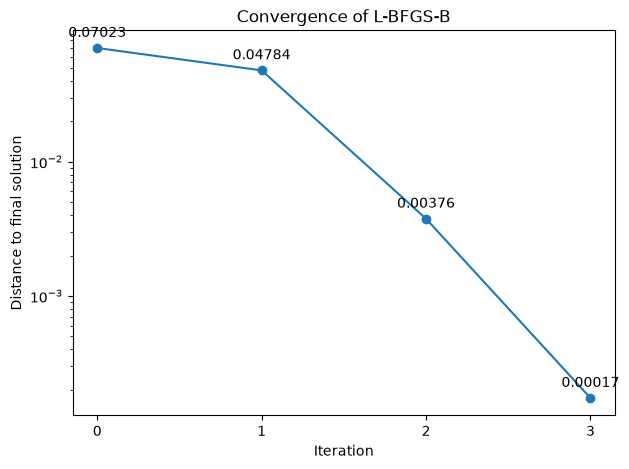

In [37]:
# the convergence plot 

# exclude the final point because its distance is zero
iterations = np.arange(len(distances) - 1)
distances_plot = distances[:-1]

# plot distance to the final solution
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(
    iterations,
    distances_plot,
    marker='o'
)

# use a logarithmic scale on the y-axis
ax.set_yscale('log')

# labels and title
ax.set_xlabel('Iteration')
ax.set_ylabel('Distance to final solution')
ax.set_title('Convergence of L-BFGS-B')

# show each iteration number on the x-axis
ax.set_xticks(iterations)

# add distance labels to each point
for i, distance in zip(iterations, distances_plot):
    ax.annotate(
        f'{distance:.5f}',
        (i, distance),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center'
    )

plt.show()

Conclusion:
The convergence path shows that L-BFGS-B moves quickly towards the optimal solution. The distance-to-final-solution plot gives a clearer picture of how fast it converges. The distance decreases from around 0.070 at the starting point to 0.048 after the first iteration, before falling much faster to 0.0038 and then 0.00017. On the log scale, we can therefore see that the distance decreases by several orders of magnitude in only a few iterations. Progress is relatively slow in the first iteration, while the largest improvements occur in the following iterations. Close to the optimum, only very small adjustments are needed. Together with the results from Question 2.2.1, this shows that L-BFGS-B is very efficient compared to the grid search, as it reaches almost the same solution using only 18 function evaluations compared to 1,000,000 with the grid search.

2.2.3 

In [43]:
# starting points for L-BFGS-B
# includes the midpoint, all four corners, and one additional point

starting_points = [
    np.array([0.5, 0.5]),   # midpoint
    np.array([0.0, 0.0]),   # bottom-left corner
    np.array([0.0, 1.0]),   # top-left corner
    np.array([1.0, 0.0]),   # bottom-right corner
    np.array([1.0, 1.0]),   # top-right corner
    np.array([0.25, 0.75])  # additional starting point
]
# test different starting points for the complements calibration

for s0 in starting_points:

    # solve from this starting point
    opt = model_comp.solve(s0=s0)

    # print the most important results in one line
    print(
        f"start={s0}, "
        f"solution=({opt.s1:.4f}, {opt.w:.4f}), "
        f"utility={opt.u:.6f}, "
        f"iterations={opt.res.nit}, "
        f"success={opt.res.success}"
    )

start=[0.5 0.5], solution=(0.5356, 0.4395), utility=3.401680, iterations=4, success=True
start=[0. 0.], solution=(0.5356, 0.4395), utility=3.401680, iterations=7, success=True
start=[0. 1.], solution=(0.5356, 0.4395), utility=3.401680, iterations=9, success=True
start=[1. 0.], solution=(1.0000, 0.0000), utility=0.000000, iterations=1, success=True
start=[1. 1.], solution=(1.0000, 1.0000), utility=0.000000, iterations=1, success=True
start=[0.25 0.75], solution=(0.5356, 0.4395), utility=3.401680, iterations=6, success=True


In [44]:
# test different starting points for the substitutes calibration

for s0 in starting_points:

    # solve from this starting point
    opt = model_sub.solve(s0=s0)

    # print the most important results in one line
    print(
        f"start={s0}, "
        f"solution=({opt.s1:.4f}, {opt.w:.4f}), "
        f"utility={opt.u:.6f}, "
        f"iterations={opt.res.nit}, "
        f"success={opt.res.success}"
    )

start=[0.5 0.5], solution=(0.5382, 0.6923), utility=3.485105, iterations=6, success=True
start=[0. 0.], solution=(0.5382, 0.6923), utility=3.485105, iterations=18, success=True
start=[0. 1.], solution=(0.5382, 0.6923), utility=3.485105, iterations=17, success=True
start=[1. 0.], solution=(0.5382, 0.6923), utility=3.485105, iterations=18, success=True
start=[1. 1.], solution=(0.5382, 0.6923), utility=3.485105, iterations=16, success=True
start=[0.25 0.75], solution=(0.5382, 0.6923), utility=3.485105, iterations=8, success=True


In [45]:
# inspect the budget shares at the two problematic corners

for s0 in [np.array([1.0, 0.0]), np.array([1.0, 1.0])]:

    # calculate the implied budget shares
    s1, s2, s3 = model_comp.shares(s0[0], s0[1])

    print("Starting point:", s0)
    print("Budget shares:", s1, s2, s3)
    print()

Starting point: [1. 0.]
Budget shares: 1.0 0.0 0.0

Starting point: [1. 1.]
Budget shares: 1.0 0.0 0.0



Conclusion:
The results show that the final solution is generally not very sensitive to the starting point. For the substitutes calibration, all six starting points converge to approximately the same optimum, s1=0.5382 and w=0.6923. For the complements calibration, most starting points also converge to the same optimum, around s1=0.5356 and w=0.4395. The number of iterations does, however, change with the starting point. Some starting values are closer to the optimum and therefore require fewer iterations, while others take longer to converge.

One special case occurs in the complements calibration at the corner where all income is spent on good 1. In the nested-share representation, both (s1,w)=(1,0) and (1,1) imply the same budget shares, (s1,s2,s3)=(1,0,0), because w is irrelevant when s1=1. From this corner, the solver stays at the boundary and returns utility close to zero, even though it reports success=True. This shows that success=True only means that the numerical stopping criteria were satisfied; it does not guarantee that the solver has found the economically relevant optimum.

2.2.4

In [46]:
# tolerance values to test

ftol_values = [1e-4, 1e-8, 1e-12, 1e-16]

gtol_values = [1e-2, 1e-5, 1e-8, 1e-12]

In [50]:
# create an empty list to store all results
results = []

# define the two calibrations
models = {
    'Complements': model_comp,
    'Substitutes': model_sub
}

# run the tests for both calibrations
for calibration, model in models.items():

    # test the different ftol values
    for ftol in ftol_values:

        opt = model.solve(
            s0=np.array([0.5, 0.5]),
            options={'ftol': ftol}
        )

        # save the results
        results.append({
            'Calibration': calibration,
            'Setting': 'ftol',
            'Tolerance': ftol,
            's1': opt.s1,
            'w': opt.w,
            'Utility': opt.u,
            'Function evaluations': opt.nfev
        })

    # test the different gtol values
    for gtol in gtol_values:

        opt = model.solve(
            s0=np.array([0.5, 0.5]),
            options={'gtol': gtol}
        )

        # save the results
        results.append({
            'Calibration': calibration,
            'Setting': 'gtol',
            'Tolerance': gtol,
            's1': opt.s1,
            'w': opt.w,
            'Utility': opt.u,
            'Function evaluations': opt.nfev
        })

In [51]:
# convert the stored results into a table
tolerance_table = pd.DataFrame(results)

# display the table
tolerance_table

,Calibration,Setting,Tolerance,s1,w,Utility,Function evaluations
0,Complements,ftol,1.000000e-04,0.535607,0.439652,3.401680,15
1,Complements,ftol,1.000000e-08,0.535623,0.439479,3.401680,18
2,Complements,ftol,1.000000e-12,0.535623,0.439479,3.401680,18
3,Complements,ftol,1.000000e-16,0.535623,0.439479,3.401680,18
4,Complements,gtol,1.000000e-02,0.535607,0.439652,3.401680,15
5,Complements,gtol,1.000000e-05,0.535623,0.439479,3.401680,18
6,Complements,gtol,1.000000e-08,0.535624,0.439478,3.401680,21
7,Complements,gtol,1.000000e-12,0.535624,0.439478,3.401680,21
8,Substitutes,ftol,1.000000e-04,0.538155,0.691562,3.485104,21
9,Substitutes,ftol,1.000000e-08,0.538225,0.692308,3.485105,27


Conclusion: 2.2.4 + 2.2.5

For both calibrations, tighter tolerances initially improve the solution, but after a certain point the solution and utility barely change. At the same time, tighter tolerances generally require more function evaluations. This shows a trade-off between precision and computational cost: after a certain point, more computation gives almost no improvement in the solution or utility. For example, using ftol = 1e-8 gives essentially the same result as ftol = 1e-12 and 1e-16. Similarly, gtol = 1e-5 is already sufficient to obtain almost the same solution as the tighter values. I would therefore use ftol = 1e-8 and gtol = 1e-5, since they give an accurate solution without unnecessary function evaluations. 

A tighter tolerance is not always better because it can require more function evaluations without meaningfully improving the solution or utility. A tighter tolerance requires the optimizer to reach a higher level of precision before it stops. This increases the computational cost, even though the optimizer does not produce a noticeably better result.